# 🚀 EmbedIA: Machine Learning en Microcontroladores

¿Imaginas ejecutar un modelo de reconocimiento de dígitos (como MNIST) en un pequeño Arduino o ESP32, sin bibliotecas pesadas ni conexión a la nube? ¡EmbedIA lo hace posible! Este framework convierte modelos de TensorFlow y Scikit-learn en código C optimizado para microcontroladores de bajo consumo.

En este tutorial, entrenaremos un modelo simple para clasificar dígitos manuscritos y lo exportaremos a C usando EmbedIA. ¡Al final, tendrás un proyecto listo para compilar y probar en hardware real!

## 🛠️ Instalación de EmbedIA desde GitHub (solo en Colab)

Si estás en Google Colab, clona el repositorio para acceder al framework.## Import framework from Github (run only in Colab)

In [1]:
!git clone https://github.com/Embed-ML/EmbedIA.git
%cd EmbedIA

fatal: destination path 'EmbedIA' already exists and is not an empty directory.
/content/EmbedIA


## 📂 Carga del Dataset

Usaremos el dataset de dígitos de Scikit-learn (similar a MNIST pero más ligero). Aplicaremos normalización para mejorar el rendimiento en microcontroladores.


In [2]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 0 to not apply normalization
# 1 for normalization [-0.5, 0.5],
# 2 for normalization z score,
_normalize = 2

def normalization0dot5(x):
    '''
        Normalization of values in the range [-0.5; 0.5]
        Params:
            x: numpy array to be normalized
        Return:
            x: normalized numpy array
    '''
    x = x/np.max(x)
    x = x-0.5
    return x

def z_score(X_train, x_test):
    '''
        Normalization z score, uses mean and standard deviation of train vector
        Params:
            X_train: array of train numpy to be normalized
            x_test: array of test numpy to be normalized
        Return:
            x_train, x_test: normalized numpy vectors
    '''
    x_mean= np.mean(X_train)
    x_std= np.std(X_train)

    x_train= (X_train-x_mean)/x_std
    x_test= (x_test-x_mean)/x_std
    return x_train, x_test

def load_dataset(_normalize):
    '''
        Load the sklearn digits dataset, applying the indicated normalization.
        Params:
            _normalize: normalization to be applied
        Return:
           X_train, X_test: training set
           y_train, y_test: test set
    '''

    digits = load_digits()

    if _normalize == 1:
        digits.images = normalization0dot5(digits.images)

    X_train, X_test, y_train, y_test = train_test_split(digits.images , digits.target, test_size=0.2, shuffle=True)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2], 1)

    if _normalize == 2:
        X_train, X_test = z_score(X_train, X_test)

    return X_train, X_test, y_train, y_test

x_train, x_test, y_train, y_test = load_dataset(_normalize)

print('x_train.shape', x_train.shape)
print(' x_test.shape', x_test.shape)

x_train.shape (1437, 8, 8, 1)
 x_test.shape (360, 8, 8, 1)


## 🖼️ Visualización de Muestras

Veamos algunos dígitos del dataset para entender los datos.

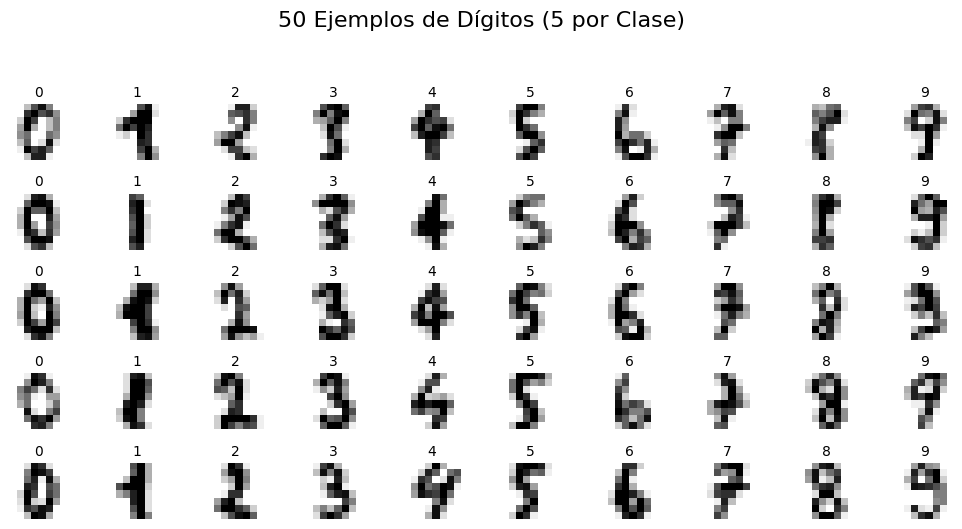

In [3]:
import matplotlib.pyplot as plt
import numpy as np

img_x_digit = 5

fig, axes = plt.subplots(5, 10, figsize=(10, 5))  # Grilla ajustado para buena proporción

for digit in range(10):
    digit_indices = np.where(y_train == digit)[0] # Encontrar índices de imágenes con el dígito actual

    for row in range(img_x_digit):
        idx = digit_indices[row] if row < len(digit_indices) else digit_indices[0]
        axes[row, digit].imshow(x_train[idx].reshape(8, 8), cmap='gray_r')
        axes[row, digit].set_title(f'{digit}', fontsize=10)
        axes[row, digit].axis('off')

plt.suptitle(f'{img_x_digit*10} Ejemplos de Dígitos ({img_x_digit} por Clase)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 🤖 Creación del Modelo

Construimos una red convolucional simple (CNN) adecuada para microcontroladores: ligera y eficiente.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, AveragePooling2D, BatchNormalization

def create_model(x_train, y_train, y_test):
    '''
        Create a model
        Input parameters:
            x_train: training data
            y_train, y_test: labels of the data involved (including test data)

        return
            model: sequential layers model
    '''
    classes = max(y_test.max(),y_train.max())+1

    model = Sequential(name="EmbedIA_model")

    model.add(Input(shape=x_train[0].shape))
    model.add(Conv2D(8, kernel_size=(3, 3),activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(16, kernel_size=(2, 2),activation='relu'))

    model.add(Flatten())
    model.add(Dense(16,activation='relu'))
    model.add(Dense(classes,activation='softmax'))

    model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['acc'])
    return model

model = create_model(x_train, y_train, y_test)
model.summary()

Model: "EmbedIA_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 6, 6, 8)        │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 16)       │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,818 (7.10 KB)

 Trainable params: 1,818 (7.10 KB)

 Non-trainable params: 0 (0.00 B)

## 🏋️‍♂️ Entrenamiento del Modelo

Entrenamos durante algunas épocas. Observa la precisión en validación.

In [5]:
epocas = 50
lote = 32

history = model.fit(x_train, y_train, epochs=epocas, batch_size=lote, validation_data=(x_test, y_test))

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.1876 - loss: 2.2668 - val_acc: 0.4028 - val_loss: 2.0308
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.3877 - loss: 1.9498 - val_acc: 0.5833 - val_loss: 1.5796
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6211 - loss: 1.4973 - val_acc: 0.7667 - val_loss: 1.0148
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7580 - loss: 0.9925 - val_acc: 0.8389 - val_loss: 0.6690
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8368 - loss: 0.6343 - val_acc: 0.8611 - val_loss: 0.5191
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8626 - loss: 0.5125 - val_acc: 0.8889 - val_loss: 0.4193
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8863 - loss: 0.4181 - val_acc: 0.8972 - val_loss: 0.3670
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9011 - loss: 0.3564 - val_acc: 0.9167 - val_loss: 0.3108
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9291 - loss: 

## 📈 Evaluación y Visualización

Graficamos la precisión de entrenamiento y validación. ¡Mira cómo converge rápidamente!

In [6]:
import plotly.express as px
import pandas as pd

# Crear DataFrame con los datos de precisión
df = pd.DataFrame({
    'Épocas': range(len(history.history['acc'])),
    'Entrenamiento': history.history['acc'],
    'Validación': history.history['val_acc']
})

# Graficar con Plotly Express
fig = px.line(df, x='Épocas', y=['Entrenamiento', 'Validación'],
              title=f'📈 Precisión del Modelo (Validación: {history.history["val_acc"][-1]:.2%})',
              labels={'value': 'Precisión', 'variable': 'Dataset'},
              color_discrete_map={'Entrenamiento': '#1f77b4', 'Validación': '#ff7f0e'})
fig.update_layout(showlegend=True, template='plotly_white',  width=1000, height=400)
fig.show()

## 💾 Guardar el Modelo

Guardamos el modelo entrenado para exportarlo.

In [7]:
model_name = "mnist_model.h5"
model.save("models/" + model_name)

## 📤 Exportación a C con EmbedIA

Ahora, la magia: convertimos el modelo a código C portable. Configura las opciones y genera el proyecto.

In [8]:
#@title ⚙️ Configurar y ejecutar exportador { display-mode: "form" }

import sys
# add parent folder to path in order to find EmbedIA folder
sys.path.insert(0, '..')

import joblib
from tensorflow.keras.models import load_model
from embedia.project_generator import ProjectGenerator
from embedia.model_generator.project_options import (
    ModelDataType,
    DebugMode,
    ProjectFiles,
    ProjectOptions,
    ProjectType
)

#@markdown ---
#@markdown ### Ajustes para Exportación

OUTPUT_FOLDER = 'outputs/' #@param {type:"string"}
PROJECT_NAME = 'mnist_project' #@param {type:"string"}

MODEL_FILE = 'models/mnist_model.h5' #@param {type:"string"}
model = load_model(MODEL_FILE)
# model.summary()

options = ProjectOptions()

# set location of EmbedIA folder
embedia_folder = '../EmbedIA/embedia'
options.embedia_folder = embedia_folder

#@markdown ---
#@markdown ###Configuración del proyecto para exportar

# set project type
project_type_dict = {
    "ARDUINO": ProjectType.ARDUINO,
    "C": ProjectType.C,
    "CODEBLOCK": ProjectType.CODEBLOCK,
    "CPP": ProjectType.CPP,
}
project_type = "CODEBLOCK" #@param ["ARDUINO", "C", "CODEBLOCK", "CPP"]
options.project_type = project_type_dict[project_type]

# set data type
data_type_dict = {
    "FLOAT": ModelDataType.FLOAT,
    "FIXED32": ModelDataType.FIXED32,
    "FIXED16": ModelDataType.FIXED16,
    "FIXED8": ModelDataType.FIXED8,
    "BINARY": ModelDataType.BINARY,
}
data_type = "FIXED16" #@param ["FLOAT", "FIXED32", "FIXED16", "FIXED8", "BINARY"]
options.data_type = data_type_dict[data_type]

# set debug mode
debug_mode_dict = {
    "DISCARD": DebugMode.DISCARD,
    "DISABLED": DebugMode.DISABLED,
    "HEADERS": DebugMode.HEADERS,
    "DATA": DebugMode.DATA,
}
debug_mode = "DATA" #@param ["DISCARD", "DISABLED", "HEADERS", "DATA"]
options.debug_mode = debug_mode_dict[debug_mode]

# set which files to export
files_export_dict = {
    "ALL": ProjectFiles.ALL(),
    "MAIN": {ProjectFiles.MAIN},
    "MODEL": {ProjectFiles.MODEL},
    "LIBRARY": {ProjectFiles.LIBRARY},
}
files_export = "ALL" #@param ["ALL", "MAIN", "MODEL", "LIBRARY"]
options.files = files_export_dict[files_export]

# examples to export
samples = x_test[0:10]
ids = y_test[0:10]

options.example_data = samples
options.example_ids = ids

#@markdown Marcar casilla para eliminar la carpeta y realizar una exportación limpia:
clean_output = True #@param {type:"boolean"}
options.clean_output = clean_output
#@markdown ---

############# Generate project #############

generator = ProjectGenerator(options)
generator.create_project(OUTPUT_FOLDER, PROJECT_NAME, model, options)

print("Project", PROJECT_NAME, "exported in", OUTPUT_FOLDER,'\n\n')


/content/EmbedIA/embedia/core/layers_implemented.py:130: UserWarning:





+---------------------+---------------+------------+------------+-------+-------+------------+
| EmbedIA Layer       | Name          | #Param(NT) |   Shape    |  MACs | ACOPs | Size (KiB) |
+---------------------+---------------+------------+------------+-------+-------+------------+
| Conv2D              | conv2d        |         80 | (6, 6, 8)  | 20736 | 23040 |     0.193  |
| Activation(relu)    | conv2d1       |          0 | (6, 6, 8)  |     0 |   864 |     0.000  |
| Pooling(max)        | max_pooling2d |          0 | (3, 3, 8)  |     0 |   576 |     0.000  |
| Conv2D              | conv2d_1      |        528 | (2, 2, 16) | 32768 | 18432 |     1.129  |
| Activation(relu)    | conv2d_11     |          0 | (2, 2, 16) |     0 |   192 |     0.000  |
| Flatten             | flatten       |          0 |   (64,)    |     0 |   128 |     0.000  |
| Dense               | dense         |       1040 |   (16,)    |  1024 |    48 |     2.062  |
| Activation(relu)    | dense1        |          

## ⬇️ Descarga el Proyecto Generado (solo en Colab)

¡Listo! Descarga el ZIP y compila en tu IDE favorito. Prueba en un microcontrolador y cuéntanos tus resultados en el repo.

In [9]:
from google.colab import files

!zip -r embedia_project.zip 'outputs/mnist_project'
files.download('/content/EmbedIA/embedia_project.zip')

updating: outputs/mnist_project/ (stored 0%)
updating: outputs/mnist_project/example_file.h (deflated 83%)
updating: outputs/mnist_project/neural_net.c (deflated 82%)
updating: outputs/mnist_project/embedia_model.h (deflated 66%)
updating: outputs/mnist_project/main.c (deflated 56%)
updating: outputs/mnist_project/mnist_project.cbp (deflated 76%)
updating: outputs/mnist_project/embedia_debug.h (deflated 54%)
updating: outputs/mnist_project/embedia_debug_def.h (deflated 69%)
updating: outputs/mnist_project/fixed.h (deflated 74%)
updating: outputs/mnist_project/embedia_model.c (deflated 68%)
updating: outputs/mnist_project/common.c (deflated 52%)
updating: outputs/mnist_project/neural_net.h (deflated 74%)
updating: outputs/mnist_project/embedia_debug.c (deflated 76%)
updating: outputs/mnist_project/fixed.c (deflated 73%)
updating: outputs/mnist_project/common.h (deflated 55%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>